<a href="https://colab.research.google.com/github/iarabertopena/ml-learning-lab/blob/main/ml_learning_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Bibliotecas

In [1]:
%%writefile requirements.txt
numpy
pandas
scipy
scikit-learn

matplotlib
seaborn
scikit-plot
autorank
tqdm
scikit-multilearn-ng

Writing requirements.txt


In [2]:
!pip install -r requirements.txt

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.6/109.6 kB 4.7 MB/s eta 0:00:00
  Created wheel for baycomp: filename=baycomp-1.0.3-py3-none-any.whl size=18027 sha256=da27f7f6ea6c2ed3d877248b6f53e943af0d178ec457f7d84879520bea46c42b
  Stored in directory: /root/.cache/pip/wheels/ff/39/6a/f87e05ad75b9d87f4eb262a897ec2fe3aab09449d13e3c3b2c
  Created wheel for liac-arff: filename=liac_arff-2.5.0-py3-none-any.whl size=11717 sha256=7959e292e9d68e87a7c66a838a549c970ab240c1a8cff0b695915ebd77df093f
  Stored in directory: /root/.cache/pip/wheels/a9/ac/cf/c2919807a5c623926d217c0a18eb5b457e5c19d242c3b5963a
Successfully built baycomp liac-arff


### Imports

In [3]:
import numpy as np
import pandas as pd

from sklearn import metrics
from sklearn.model_selection import StratifiedKFold
from skmultilearn.model_selection import IterativeStratification
from sklearn.model_selection import KFold
from sklearn.metrics import hamming_loss, f1_score, roc_auc_score, average_precision_score
from sklearn.ensemble import RandomForestClassifier
from skmultilearn.problem_transform import BinaryRelevance, LabelPowerset
from skmultilearn.ensemble import RakelD
from skmultilearn.adapt import MLkNN

from tqdm import tqdm

### Datasets

In [65]:
# Definir dataset
import pandas as pd

#df = pd.read_csv("/content/flags.csv")
df = pd.read_csv("/content/Gram_positive.csv")
df.head()

,attr0,attr1,attr2,attr3,attr4,attr5,attr6,attr7,attr8,attr9,...,attr906,attr907,attr908,attr909,attr910,attr911,label0,label1,label2,label3
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0


In [6]:
df = pd.read_csv("/content/CHD_49.csv")
df.head()

,attr0,attr1,attr2,attr3,attr4,attr5,attr6,attr7,attr8,attr9,...,attr45,attr46,attr47,attr48,label0,label1,label2,label3,label4,label5
0,1.0,-1.0,1.0,-1.0,1.0,1.0,0.0,-0.5,1.0,1.0,...,1.0,1.0,1.0,1.0,1,0,1,0,1,1
1,-1.0,-1.0,-1.0,-1.0,1.0,1.0,-1.0,-1.0,-1.0,-1.0,...,1.0,1.0,1.0,-1.0,1,0,0,1,0,0
2,-1.0,1.0,-1.0,-1.0,1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,-1.0,1.0,-1.0,1.0,0,1,0,0,0,1
3,1.0,1.0,-1.0,1.0,-1.0,1.0,0.0,-0.5,1.0,1.0,...,-1.0,1.0,1.0,-1.0,0,1,0,0,0,1
4,-1.0,-1.0,-1.0,1.0,1.0,1.0,0.0,-0.5,-1.0,1.0,...,-1.0,-1.0,-1.0,-1.0,0,0,1,0,0,1


In [7]:
df = pd.read_csv("/content/VirusGO.csv")
df.head()

,attr0,attr1,attr2,attr3,attr4,attr5,attr6,attr7,attr8,attr9,...,attr745,attr746,attr747,attr748,label0,label1,label2,label3,label4,label5
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0


In [8]:
df = pd.read_csv("/content/emotions.csv")
df.head()

,Mean_Acc1298_Mean_Mem40_Centroid,Mean_Acc1298_Mean_Mem40_Rolloff,Mean_Acc1298_Mean_Mem40_Flux,Mean_Acc1298_Mean_Mem40_MFCC_0,Mean_Acc1298_Mean_Mem40_MFCC_1,Mean_Acc1298_Mean_Mem40_MFCC_2,Mean_Acc1298_Mean_Mem40_MFCC_3,Mean_Acc1298_Mean_Mem40_MFCC_4,Mean_Acc1298_Mean_Mem40_MFCC_5,Mean_Acc1298_Mean_Mem40_MFCC_6,...,BH_HighLowRatio,BHSUM1,BHSUM2,BHSUM3,label_amazed-suprised,label_happy-pleased,label_relaxing-calm,label_quiet-still,label_sad-lonely,label_angry-aggresive
0,0.034741,0.089665,0.091225,-73.302422,6.215179,0.615074,2.037160,0.804065,1.301409,0.558576,...,2,0.245457,0.105065,0.405399,0,1,1,0,0,0
1,0.081374,0.272747,0.085733,-62.584437,3.183163,-0.218145,0.163038,0.620251,0.458514,0.041426,...,2,0.343547,0.276366,0.710924,1,0,0,0,0,1
2,0.110545,0.273567,0.084410,-65.235325,2.794964,0.639047,1.281297,0.757896,0.489412,0.627636,...,3,0.188693,0.045941,0.457372,0,1,0,0,0,1
3,0.042481,0.199281,0.093447,-80.305152,5.824409,0.648848,1.754870,1.495532,0.739909,0.809644,...,2,0.102839,0.241934,0.351009,0,0,1,0,0,0
4,0.074550,0.140880,0.079789,-93.697749,5.543229,1.064262,0.899152,0.890336,0.702328,0.490685,...,2,0.195196,0.310801,0.683817,0,0,0,1,0,0


In [9]:
df = pd.read_csv("/content/VirusPseAAC.csv")
df.head()

,attr0,attr1,attr2,attr3,attr4,attr5,attr6,attr7,attr8,attr9,...,attr436,attr437,attr438,attr439,label_0,label_1,label_2,label_3,label_4,label_5
0,4.083,0.000,2.675,5.490,0.282,5.913,0.845,2.675,4.364,2.252,...,0.216,0.456,0.133,0.535,1.0,0.0,0.0,0.0,0.0,0.0
1,3.844,0.000,2.705,5.837,0.427,5.694,0.712,2.420,4.271,2.278,...,0.174,0.464,0.166,0.566,1.0,0.0,0.0,0.0,0.0,0.0
2,3.991,0.000,2.708,5.701,0.285,5.701,0.855,2.565,4.418,2.423,...,0.170,0.456,0.124,0.547,1.0,0.0,0.0,0.0,0.0,0.0
3,4.284,0.000,2.571,5.284,0.286,5.284,0.857,2.856,4.856,2.285,...,0.140,0.411,0.112,0.491,1.0,0.0,0.0,0.0,0.0,0.0
4,4.557,0.138,2.486,4.972,0.276,5.110,0.829,2.348,4.143,2.348,...,0.382,0.573,0.220,0.653,1.0,0.0,0.0,0.0,0.0,0.0


In [66]:
datasets_config = {
    "Gram_positive": {"path": "/content/Gram_positive.csv", "n_labels": 4},
    #"flags": {"path": "/content/flags.csv", "n_labels": 6},
    "CHD_49": {"path": "/content/CHD_49.csv", "n_labels": 6},
    "VirusGO": {"path": "/content/VirusGO.csv", "n_labels": 6},
    "emotions": {"path": "/content/emotions.csv", "n_labels": 6},
    "VirusPseAAC": {"path": "/content/VirusPseAAC.csv", "n_labels": 6}
}

def load_dataset(path, n_labels):
    df = pd.read_csv(path)

    X = df.iloc[:, :-n_labels]
    Y = df.iloc[:, -n_labels:]

    # converter categóricos
    X = pd.get_dummies(X)

    # !!!
    X = np.array(X)
    Y = np.array(Y)

    if len(Y.shape) == 1:
        Y = Y.reshape(-1, 1)

    Y = Y.astype(int)
    # !!!

    #return X.values, Y.values
    return X, Y

# carregar tudo em um dicionário
datasets = {
    name: load_dataset(cfg["path"], cfg["n_labels"])
    for name, cfg in datasets_config.items()
}

# acessar os dados
for name, (X, Y) in datasets.items():
    print(f"{name}: X={X.shape}, Y={Y.shape}")

Gram_positive: X=(519, 912), Y=(519, 4)
CHD_49: X=(555, 49), Y=(555, 6)
VirusGO: X=(207, 749), Y=(207, 6)
emotions: X=(593, 72), Y=(593, 6)
VirusPseAAC: X=(207, 440), Y=(207, 6)


### 5 fold cross validation (iterative stratification for multi-label data)

In [67]:
def multilabel_cv_splits(X, Y, n_splits=5):
    stratifier = IterativeStratification(n_splits=n_splits, order=1)

    splits = []
    for train_idx, test_idx in stratifier.split(X, Y):
        splits.append((train_idx, test_idx))

    return splits

### Métricas de avaliação

In [68]:
def evaluate_metrics(y_true, y_pred, y_prob):

    results = {}

    # binarizar (threshold 0.5)
    y_pred_bin = (y_prob >= 0.5).astype(int)

    results["hamming"] = hamming_loss(y_true, y_pred_bin)

    results["f1_micro"] = f1_score(y_true, y_pred_bin, average='micro')
    results["f1_macro"] = f1_score(y_true, y_pred_bin, average='macro')

    try:
      results["auprc_micro"] = average_precision_score(y_true, y_prob, average='micro')
      results["auprc_macro"] = average_precision_score(y_true, y_prob, average='macro')
    except:
      results["auprc_micro"] = np.nan
      results["auprc_macro"] = np.nan

    try:
      results["auc_micro"] = roc_auc_score(y_true, y_prob, average='micro')
      results["auc_macro"] = roc_auc_score(y_true, y_prob, average='macro')
    except:
      results["auc_micro"] = np.nan
      results["auc_macro"] = np.nan

    return results

In [69]:
# Hamming Loss:
# Proporção de labels incorretamente previstas (falsos positivos + falsos negativos).
# Quanto menor, melhor.

# F1-score (micro):
# Agrega contribuições de todas as classes.
# Favorece classes mais frequentes.

# F1-score (macro):
# Calcula F1 por classe e tira média.
# Dá o mesmo peso para classes raras e frequentes.


# AUPRC (Área sob a curva Precision-Recall):
# Mais informativa que AUC quando há desbalanceamento.
# Mede qualidade das probabilidades previstas.
    # Micro: avalia globalmente (classes frequentes têm mais peso)
    # Macro: média entre classes (importante para labels raros)

# AUC:
# Mede a capacidade do modelo de separar classes positivas e negativas.
    # Micro: mais influenciado por classes frequentes
    # Macro: trata todas as classes igualmente

### Algoritmos

#### Definindo os modelos:

In [70]:
# Definindo os modelos:
def get_models():
    return {
        "BR": BinaryRelevance(
            classifier=RandomForestClassifier(n_estimators=100, random_state=42)
        ),

        "LP": LabelPowerset(
            classifier=RandomForestClassifier(n_estimators=100, random_state=42)
        ),

        "RAkEL": RakelD(
            base_classifier=RandomForestClassifier(n_estimators=100, random_state=42),
            labelset_size=2
        ),

        "RF": RandomForestClassifier(n_estimators=100, random_state=42),

        "MLkNN": MLkNN(k=10)
    }

In [71]:
# BR (Binary Relevance):
# Decompõe o problema multi-label em vários classificadores binários independentes.
# Simples e eficiente, mas ignora correlação entre labels.

# LP (Label Powerset):
# Transforma o problema multi-label em multi-classe usando combinações de labels.
# Captura dependências, mas pode gerar muitas classes distintas.

# RAkEL:
# Usa vários modelos LP em subconjuntos aleatórios de labels.
# Reduz a complexidade do LP e mantém parte das dependências.

# MLkNN:
# Extensão do kNN para multi-label baseada em probabilidade.
# Considera vizinhos mais próximos e estima a probabilidade de cada label.
# Consegue capturar dependência local entre labels.

# Random Forest (adaptado para multi-label):
# Conjunto de árvores de decisão usado como classificador base.
# Robusto a ruído e capaz de modelar relações não lineares.
# Quando usado com BR ou LP, herda suas características.

### Loop principal:

In [72]:
import numpy as np

def run_experiment(X, Y, models):
    splits = multilabel_cv_splits(X, Y)

    results = {name: [] for name in models.keys()}

    for train_idx, test_idx in splits:
        X_train, X_test = X[train_idx], X[test_idx]
        Y_train, Y_test = Y[train_idx], Y[test_idx]

        for name in models:
          #model = get_models()[name]
          model = models[name]
          print(f"\nTreinando {name}...")

          try:
            model.fit(X_train, Y_train)
            y_pred = model.predict(X_test)
            #y_prob = model.predict_proba(X_test)

            #y_pred = model.predict(X_test).toarray()
            if hasattr(y_pred, "toarray"):
              y_pred = y_pred.toarray()

            print(f"Modelo: {name}")
            #print("Predições (primeiras linhas):")
            #print(y_pred[:5])
            #print("Soma total:", y_pred.sum())

            y_prob = None
            if hasattr(model, "predict_proba"):
              try:
                y_prob = model.predict_proba(X_test)

                if isinstance(y_prob, list):
                  y_prob = np.array([p[:, 1] for p in y_prob]).T

                if hasattr(y_prob, "toarray"):
                 y_prob = y_prob.toarray()

              except:
                y_prob = None

            res = evaluate_metrics(Y_test, y_pred, y_prob)
            print("Resultado:", res)
            results[name].append(res)

          except Exception as e:
            print(f"Erro no modelo {name}: {e}")

    return results

In [73]:
results = run_experiment(X, Y, get_models())


Treinando BR...
Modelo: BR
Resultado: {'hamming': 0.18699186991869918, 'f1_micro': 0.25806451612903225, 'f1_macro': 0.11201079622132254, 'auprc_micro': np.float64(0.45640505329243897), 'auprc_macro': np.float64(0.3715936666432511), 'auc_micro': np.float64(0.7882855706385118), 'auc_macro': np.float64(0.6584441640707624)}

Treinando LP...
Modelo: LP
Resultado: {'hamming': 0.22357723577235772, 'f1_micro': 0.09836065573770492, 'f1_macro': 0.04545454545454545, 'auprc_micro': np.float64(0.4139167568748807), 'auprc_macro': np.float64(0.3609253401347405), 'auc_micro': np.float64(0.7860231271995978), 'auc_macro': np.float64(0.6197890767583862)}

Treinando RAkEL...
Modelo: RAkEL
Resultado: {'hamming': 0.2073170731707317, 'f1_micro': 0.2153846153846154, 'f1_macro': 0.09797101449275362, 'auprc_micro': np.float64(0.43351666446625703), 'auprc_macro': np.float64(0.3601230308250654), 'auc_micro': np.float64(0.7870789341377576), 'auc_macro': np.float64(0.6485689938695053)}

Treinando RF...
Modelo: RF


In [74]:
# Resumindo os resultados:
def summarize_results(results):
    summary = {}

    for model, res_list in results.items():

        # pula modelos vazios (por conta do MKnn)
        if len(res_list) == 0:
            print(f"{model} sem resultados, ignorando... :/")
            continue

        summary[model] = {}

        for metric in res_list[0].keys():
            values = [
                r[metric]
                for r in res_list
                if r[metric] is not None and not np.isnan(r[metric])
            ]

            if len(values) > 0:
                summary[model][metric] = (
                    np.mean(values),
                    np.std(values)
                )
            else:
                summary[model][metric] = (np.nan, np.nan)

    return summary

In [75]:
summary = summarize_results(results)

for model, metrics in summary.items():
    print(f"\n--- {model} ---")
    for k, (mean, std) in metrics.items():
        if np.isnan(mean):
            print(f"{k}: nan")
        else:
            print(f"{k}: {mean:.4f} ± {std:.4f}")


--- BR ---
hamming: 0.1957 ± 0.0075
f1_micro: 0.3128 ± 0.0380
f1_macro: 0.1684 ± 0.0485
auprc_micro: 0.4314 ± 0.0276
auprc_macro: 0.3516 ± 0.0544
auc_micro: 0.7749 ± 0.0154
auc_macro: 0.5987 ± 0.0384

--- LP ---
hamming: 0.2142 ± 0.0118
f1_micro: 0.1775 ± 0.0589
f1_macro: 0.0939 ± 0.0409
auprc_micro: 0.4336 ± 0.0466
auprc_macro: 0.3510 ± 0.0759
auc_micro: 0.7854 ± 0.0131
auc_macro: 0.6215 ± 0.0519

--- RAkEL ---
hamming: 0.2119 ± 0.0089
f1_micro: 0.1763 ± 0.0607
f1_macro: 0.0936 ± 0.0524
auprc_micro: 0.4202 ± 0.0181
auprc_macro: 0.3546 ± 0.0491
auc_micro: 0.7772 ± 0.0137
auc_macro: 0.6193 ± 0.0197

--- RF ---
hamming: 0.2014 ± 0.0181
f1_micro: 0.1891 ± 0.0949
f1_macro: 0.1003 ± 0.0567
auprc_micro: 0.4425 ± 0.0691
auprc_macro: 0.3725 ± 0.0764
auc_micro: 0.7797 ± 0.0230
auc_macro: 0.6191 ± 0.0574

--- MLkNN ---
hamming: 0.2153 ± 0.0114
f1_micro: 0.3088 ± 0.0350
f1_macro: 0.1280 ± 0.0142
auprc_micro: 0.4221 ± 0.0359
auprc_macro: 0.3306 ± 0.0566
auc_micro: 0.7700 ± 0.0206
auc_macro: 0.587

### Rodando os 5 datasets:

In [76]:
all_results = {}

for name, (X, Y) in datasets.items():
    print(f"\n====================")
    print(f"Dataset: {name}")
    print(f"====================")

    results = run_experiment(X, Y, get_models())
    summary = summarize_results(results)

    all_results[name] = summary


Dataset: Gram_positive

Treinando BR...
Modelo: BR
Resultado: {'hamming': 0.024509803921568627, 'f1_micro': 0.95, 'f1_macro': 0.9062253666731279, 'auprc_micro': np.float64(0.9870875708274688), 'auprc_macro': np.float64(0.9532218306590772), 'auc_micro': np.float64(0.9944134967372275), 'auc_macro': np.float64(0.9927602628132473)}

Treinando LP...
Modelo: LP
Resultado: {'hamming': 0.024509803921568627, 'f1_micro': 0.95, 'f1_macro': 0.9062253666731279, 'auprc_micro': np.float64(0.9881053987210431), 'auprc_macro': np.float64(0.9560205361214253), 'auc_micro': np.float64(0.9950819672131147), 'auc_macro': np.float64(0.9942617127521972)}

Treinando RAkEL...
Modelo: RAkEL
Resultado: {'hamming': 0.024509803921568627, 'f1_micro': 0.95, 'f1_macro': 0.9062253666731279, 'auprc_micro': np.float64(0.9891462737014386), 'auprc_macro': np.float64(0.9557750859298545), 'auc_micro': np.float64(0.9957504376890021), 'auc_macro': np.float64(0.9942617127521972)}

Treinando RF...
Modelo: RF
Resultado: {'hamming'

### Tabelas de resultados:

In [86]:
import pandas as pd

rows = []

for dataset_name, models in all_results.items():
    row = {"dataset": dataset_name}

    for model_name, metrics in models.items():
        mean, _ = metrics["hamming"]
        row[model_name] = mean

    rows.append(row)

df = pd.DataFrame(rows)
df = df.set_index("dataset")

print("Tabela de resultados: hamming loss")
print(df)

best_hamming = df.idxmin(axis=1)  # porque hamming é menor melhor
print("\nMelhor modelo por dataset:")
print(best_hamming)

Tabela de resultados: hamming loss
                     BR        LP     RAkEL        RF     MLkNN
dataset                                                        
Gram_positive  0.028855  0.029345  0.025974  0.029345  0.033243
CHD_49         0.285299  0.285549  0.287404  0.279299  0.311635
VirusGO        0.054837  0.057131  0.055366  0.059868  0.073506
emotions       0.181805  0.178459  0.185417  0.183084  0.260486
VirusPseAAC    0.209787  0.208301  0.206576  0.204467  0.214099

Melhor modelo por dataset:
dataset
Gram_positive    RAkEL
CHD_49              RF
VirusGO             BR
emotions            LP
VirusPseAAC         RF
dtype: object


In [87]:
import pandas as pd

rows = []

for dataset_name, models in all_results.items():
    row = {"dataset": dataset_name}

    for model_name, metrics in models.items():
        mean, _ = metrics["f1_micro"]
        row[model_name] = mean

    rows.append(row)

df = pd.DataFrame(rows)
df = df.set_index("dataset")

print("Tabela de resultados: f1_micro")
print(df)

best_f1_micro = df.idxmax(axis=1)
print("\nMelhor modelo por dataset:")
print(best_f1_micro)

Tabela de resultados: f1_micro
                     BR        LP     RAkEL        RF     MLkNN
dataset                                                        
Gram_positive  0.941900  0.940972  0.947818  0.940972  0.932789
CHD_49         0.671191  0.664040  0.668791  0.671480  0.636612
VirusGO        0.861236  0.851289  0.857999  0.845768  0.806949
emotions       0.679968  0.682035  0.671737  0.671104  0.525711
VirusPseAAC    0.267781  0.192359  0.224852  0.163630  0.308301

Melhor modelo por dataset:
dataset
Gram_positive    RAkEL
CHD_49              RF
VirusGO             BR
emotions            LP
VirusPseAAC      MLkNN
dtype: object


In [88]:
import pandas as pd

rows = []

for dataset_name, models in all_results.items():
    row = {"dataset": dataset_name}

    for model_name, metrics in models.items():
        mean, _ = metrics["f1_macro"]
        row[model_name] = mean

    rows.append(row)

df = pd.DataFrame(rows)
df = df.set_index("dataset")

print("Tabela de resultados: f1_macro")
print(df)

best_f1_macro = df.idxmax(axis=1)
print("\nMelhor modelo por dataset:")
print(best_f1_macro)

Tabela de resultados: f1_macro
                     BR        LP     RAkEL        RF     MLkNN
dataset                                                        
Gram_positive  0.827924  0.827175  0.845478  0.827175  0.819800
CHD_49         0.489664  0.462782  0.486645  0.481963  0.460149
VirusGO        0.853196  0.847111  0.852892  0.829588  0.671241
emotions       0.647948  0.646196  0.641005  0.635871  0.464748
VirusPseAAC    0.147457  0.116734  0.130814  0.106896  0.154509

Melhor modelo por dataset:
dataset
Gram_positive    RAkEL
CHD_49              BR
VirusGO             BR
emotions            BR
VirusPseAAC      MLkNN
dtype: object


In [89]:
import pandas as pd

rows = []

for dataset_name, models in all_results.items():
    row = {"dataset": dataset_name}

    for model_name, metrics in models.items():
        mean, _ = metrics["auprc_micro"]
        row[model_name] = mean

    rows.append(row)

df = pd.DataFrame(rows)
df = df.set_index("dataset")

print("Tabela de resultados: auprc_micro")
print(df)

best_auprc_micro = df.idxmax(axis=1)
print("\nMelhor modelo por dataset:")
print(best_auprc_micro)

Tabela de resultados: auprc_micro
                     BR        LP     RAkEL        RF     MLkNN
dataset                                                        
Gram_positive  0.979991  0.981728  0.980075  0.979588  0.967367
CHD_49         0.689957  0.702665  0.697721  0.704368  0.661433
VirusGO        0.920755  0.927601  0.919951  0.925833  0.874636
emotions       0.753231  0.755880  0.746156  0.757390  0.586127
VirusPseAAC    0.409863  0.414805  0.426590  0.444324  0.421135

Melhor modelo por dataset:
dataset
Gram_positive    LP
CHD_49           RF
VirusGO          LP
emotions         RF
VirusPseAAC      RF
dtype: object


In [90]:
import pandas as pd

rows = []

for dataset_name, models in all_results.items():
    row = {"dataset": dataset_name}

    for model_name, metrics in models.items():
        mean, _ = metrics["auprc_macro"]
        row[model_name] = mean

    rows.append(row)

df = pd.DataFrame(rows)
df = df.set_index("dataset")

print("Tabela de resultados: auprc_macro")
print(df)

best_auprc_macro = df.idxmax(axis=1)
print("\nMelhor modelo por dataset:")
print(best_auprc_macro)

Tabela de resultados: auprc_macro
                     BR        LP     RAkEL        RF     MLkNN
dataset                                                        
Gram_positive  0.915586  0.932742  0.938632  0.930515  0.887180
CHD_49         0.525957  0.537241  0.528943  0.538259  0.483657
VirusGO        0.940699  0.944740  0.938351  0.936461  0.795935
emotions       0.735895  0.747156  0.735893  0.740640  0.534671
VirusPseAAC    0.349886  0.352312  0.359254  0.377060  0.328424

Melhor modelo por dataset:
dataset
Gram_positive    RAkEL
CHD_49              RF
VirusGO             LP
emotions            LP
VirusPseAAC         RF
dtype: object


In [91]:
import pandas as pd

rows = []

for dataset_name, models in all_results.items():
    row = {"dataset": dataset_name}

    for model_name, metrics in models.items():
        mean, _ = metrics["auc_micro"]
        row[model_name] = mean

    rows.append(row)

df = pd.DataFrame(rows)
df = df.set_index("dataset")

print("Tabela de resultados: auc_micro")
print(df)

best_auc_micro = df.idxmax(axis=1)
print("\nMelhor modelo por dataset:")
print(best_auc_micro)

Tabela de resultados: auc_micro
                     BR        LP     RAkEL        RF     MLkNN
dataset                                                        
Gram_positive  0.992741  0.992251  0.991942  0.991885  0.985998
CHD_49         0.785763  0.791198  0.788706  0.794110  0.760858
VirusGO        0.979013  0.979290  0.981577  0.979385  0.958579
emotions       0.872437  0.874611  0.872242  0.875396  0.763365
VirusPseAAC    0.768864  0.777716  0.776805  0.789049  0.767955

Melhor modelo por dataset:
dataset
Gram_positive       BR
CHD_49              RF
VirusGO          RAkEL
emotions            RF
VirusPseAAC         RF
dtype: object


In [92]:
import pandas as pd

rows = []

for dataset_name, models in all_results.items():
    row = {"dataset": dataset_name}

    for model_name, metrics in models.items():
        mean, _ = metrics["auc_macro"]
        row[model_name] = mean

    rows.append(row)

df = pd.DataFrame(rows)
df = df.set_index("dataset")

print("Tabela de resultados: auc_macro")
print(df)

best_auc_macro = df.idxmax(axis=1)
print("\nMelhor modelo por dataset:")
print(best_auc_macro)

Tabela de resultados: auc_macro
                     BR        LP     RAkEL        RF     MLkNN
dataset                                                        
Gram_positive  0.989504  0.989061  0.988732  0.988538  0.976438
CHD_49         0.568273  0.589233  0.575007  0.585367  0.539308
VirusGO        0.976501  0.976569  0.977255  0.975472  0.942499
emotions       0.853308  0.857343  0.853613  0.855372  0.737049
VirusPseAAC    0.603236  0.610504  0.600570  0.638906  0.599473

Melhor modelo por dataset:
dataset
Gram_positive       BR
CHD_49              LP
VirusGO          RAkEL
emotions            LP
VirusPseAAC         RF
dtype: object


In [93]:
def build_table(all_results, metric_name):
    rows = []

    for dataset_name, models in all_results.items():
        row = {"dataset": dataset_name}

        for model_name, metrics in models.items():
            mean, _ = metrics[metric_name]
            row[model_name] = mean

        rows.append(row)

    df = pd.DataFrame(rows)
    df = df.set_index("dataset")

    return df

In [94]:
metrics = [
    "hamming",
    "f1_micro",
    "f1_macro",
    "auprc_micro",
    "auprc_macro",
    "auc_micro",
    "auc_macro"
]

for metric in metrics:
    print(f"\n===== {metric.upper()} =====")

    df = build_table(all_results, metric)

    print(df.to_string())


===== HAMMING =====
                     BR        LP     RAkEL        RF     MLkNN
dataset                                                        
Gram_positive  0.028855  0.029345  0.025974  0.029345  0.033243
CHD_49         0.285299  0.285549  0.287404  0.279299  0.311635
VirusGO        0.054837  0.057131  0.055366  0.059868  0.073506
emotions       0.181805  0.178459  0.185417  0.183084  0.260486
VirusPseAAC    0.209787  0.208301  0.206576  0.204467  0.214099

===== F1_MICRO =====
                     BR        LP     RAkEL        RF     MLkNN
dataset                                                        
Gram_positive  0.941900  0.940972  0.947818  0.940972  0.932789
CHD_49         0.671191  0.664040  0.668791  0.671480  0.636612
VirusGO        0.861236  0.851289  0.857999  0.845768  0.806949
emotions       0.679968  0.682035  0.671737  0.671104  0.525711
VirusPseAAC    0.267781  0.192359  0.224852  0.163630  0.308301

===== F1_MACRO =====
                     BR        LP     R

### Testes estatísticos

#### Hamming Loss


===== HAMMING =====
                     BR        LP     RAkEL        RF     MLkNN
dataset                                                        
Gram_positive  0.028855  0.029345  0.025974  0.029345  0.033243
CHD_49         0.285299  0.285549  0.287404  0.279299  0.311635
VirusGO        0.054837  0.057131  0.055366  0.059868  0.073506
emotions       0.181805  0.178459  0.185417  0.183084  0.260486
VirusPseAAC    0.209787  0.208301  0.206576  0.204467  0.214099
Fail to reject null hypothesis that data is normal for column BR (p=0.575839>=0.010000)
Fail to reject null hypothesis that data is normal for column LP (p=0.627504>=0.010000)
Fail to reject null hypothesis that data is normal for column RAkEL (p=0.580954>=0.010000)
Fail to reject null hypothesis that data is normal for column RF (p=0.596554>=0.010000)
Fail to reject null hypothesis that data is normal for column MLkNN (p=0.503884>=0.010000)
Using Bartlett's test for homoscedacity of normally distributed data
Fail to reject n

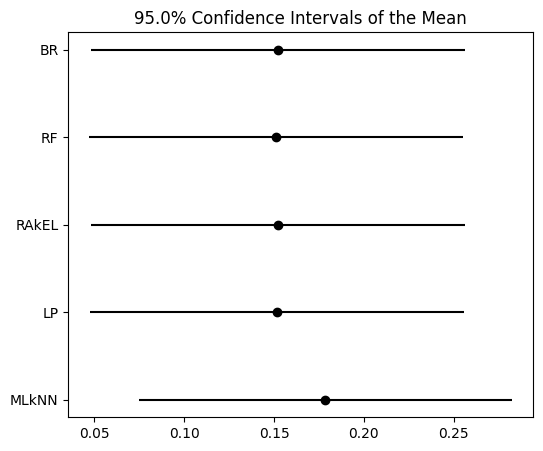


Wilcoxon: RF vs LP
p-valor: 0.875


In [95]:
from autorank import autorank, plot_stats
from scipy.stats import wilcoxon
import matplotlib.pyplot as plt

print("\n===== HAMMING =====")

# tabela
df = build_table(all_results, "hamming")
df = df.dropna()
#df = df.drop(columns=["RAkEL"]) # RAkEL não funcionou com o dataset "flags" :/

print(df)

# Friedman + Nemenyi
result = autorank(df, alpha=0.05, order='ascending', verbose=True)

print("\nRanking médio:")
print(result.rankdf)

#plot_stats(result)
#plt.show()

plot_stats(result, allow_insignificant=True)
plt.show()

# Wilcoxon (só com os 2 melhores)
means = df.mean().sort_values(ascending=True)
m1, m2 = means.index[:2]

stat, p = wilcoxon(df[m1], df[m2])

print(f"\nWilcoxon: {m1} vs {m2}")
print("p-valor:", p)

Não foram observadas diferenças estatisticamente significativas entre os modelos (p = 0.520). Embora o Random Forest (RF) apresente o melhor ranking médio (menor Hamming Loss), as diferenças são negligenciáveis. O teste de Wilcoxon também não indicou diferença significativa entre os modelos comparados (p = 0.3125).

#### F1-score


===== F1_micro =====
                     BR        LP     RAkEL        RF     MLkNN
dataset                                                        
Gram_positive  0.941900  0.940972  0.947818  0.940972  0.932789
CHD_49         0.671191  0.664040  0.668791  0.671480  0.636612
VirusGO        0.861236  0.851289  0.857999  0.845768  0.806949
emotions       0.679968  0.682035  0.671737  0.671104  0.525711
VirusPseAAC    0.267781  0.192359  0.224852  0.163630  0.308301
Fail to reject null hypothesis that data is normal for column BR (p=0.404688>=0.010000)
Fail to reject null hypothesis that data is normal for column LP (p=0.311839>=0.010000)
Fail to reject null hypothesis that data is normal for column RAkEL (p=0.364150>=0.010000)
Fail to reject null hypothesis that data is normal for column RF (p=0.255304>=0.010000)
Fail to reject null hypothesis that data is normal for column MLkNN (p=0.961479>=0.010000)
Using Bartlett's test for homoscedacity of normally distributed data
Fail to reject 

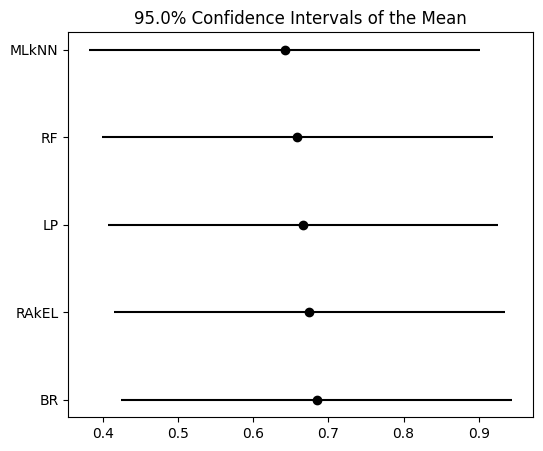


Wilcoxon: MLkNN vs RF
p-valor: 0.4375


In [96]:
from autorank import autorank, plot_stats
from scipy.stats import wilcoxon
import matplotlib.pyplot as plt

print("\n===== F1_micro =====")

# tabela
df = build_table(all_results, "f1_micro")
df = df.dropna()

print(df)

# Friedman + Nemenyi
result = autorank(df, alpha=0.05, order='descending', verbose=True)

print("\nRanking médio:")
print(result.rankdf)

#plot_stats(result)
#plt.show()

plot_stats(result, allow_insignificant=True)
plt.show()

# Wilcoxon (só com os 2 melhores)
means = df.mean().sort_values(ascending=True)
m1, m2 = means.index[:2]

stat, p = wilcoxon(df[m1], df[m2])

print(f"\nWilcoxon: {m1} vs {m2}")
print("p-valor:", p)

Conclusão: Não foram observadas diferenças estatisticamente significativas entre os modelos (p = 0.209). Embora o Binary Relevance (BR) apresente o melhor ranking médio, as diferenças são negligenciáveis. O teste de Wilcoxon também não indicou diferença significativa entre os modelos comparados (p = 0.125).


===== F1_macro =====
                     BR        LP     RAkEL        RF     MLkNN
dataset                                                        
Gram_positive  0.827924  0.827175  0.845478  0.827175  0.819800
CHD_49         0.489664  0.462782  0.486645  0.481963  0.460149
VirusGO        0.853196  0.847111  0.852892  0.829588  0.671241
emotions       0.647948  0.646196  0.641005  0.635871  0.464748
VirusPseAAC    0.147457  0.116734  0.130814  0.106896  0.154509
Fail to reject null hypothesis that data is normal for column BR (p=0.438346>=0.010000)
Fail to reject null hypothesis that data is normal for column LP (p=0.411546>=0.010000)
Fail to reject null hypothesis that data is normal for column RAkEL (p=0.384216>=0.010000)
Fail to reject null hypothesis that data is normal for column RF (p=0.322166>=0.010000)
Fail to reject null hypothesis that data is normal for column MLkNN (p=0.821386>=0.010000)
Using Bartlett's test for homoscedacity of normally distributed data
Fail to reject 

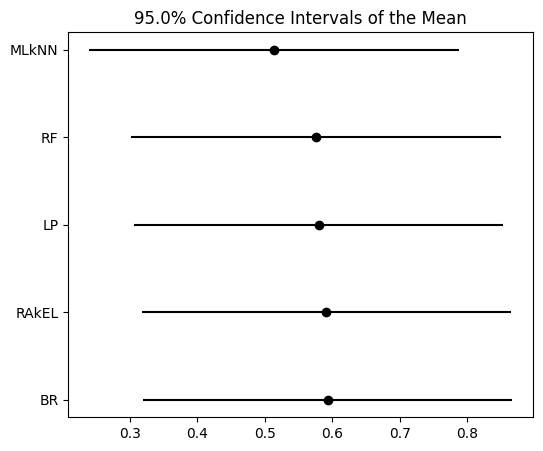


Wilcoxon: MLkNN vs RF
p-valor: 0.3125


In [97]:
from autorank import autorank, plot_stats
from scipy.stats import wilcoxon
import matplotlib.pyplot as plt

print("\n===== F1_macro =====")

# tabela
df = build_table(all_results, "f1_macro")
df = df.dropna()

print(df)

# Friedman + Nemenyi
result = autorank(df, alpha=0.05, order='descending', verbose=True)

print("\nRanking médio:")
print(result.rankdf)

#plot_stats(result)
#plt.show()

plot_stats(result, allow_insignificant=True)
plt.show()

# Wilcoxon (só com os 2 melhores)
means = df.mean().sort_values(ascending=True)
m1, m2 = means.index[:2]

stat, p = wilcoxon(df[m1], df[m2])

print(f"\nWilcoxon: {m1} vs {m2}")
print("p-valor:", p)

Conclusão:Foram observadas diferenças estatisticamente significativas entre os modelos (p = 0.016). O modelo Binary Relevance (BR) apresentou o melhor ranking médio, seguido por Random Forest (RF) e Label Powerset (LP). No entanto, os tamanhos de efeito são negligenciáveis. O teste de Wilcoxon entre os modelos comparados não indicou diferença significativa (p = 0.0625).

#### AUPRC


===== AUPRC_micro =====
                     BR        LP     RAkEL        RF     MLkNN
dataset                                                        
Gram_positive  0.979991  0.981728  0.980075  0.979588  0.967367
CHD_49         0.689957  0.702665  0.697721  0.704368  0.661433
VirusGO        0.920755  0.927601  0.919951  0.925833  0.874636
emotions       0.753231  0.755880  0.746156  0.757390  0.586127
VirusPseAAC    0.409863  0.414805  0.426590  0.444324  0.421135
Fail to reject null hypothesis that data is normal for column BR (p=0.652974>=0.010000)
Fail to reject null hypothesis that data is normal for column LP (p=0.601751>=0.010000)
Fail to reject null hypothesis that data is normal for column RAkEL (p=0.663528>=0.010000)
Fail to reject null hypothesis that data is normal for column RF (p=0.654619>=0.010000)
Fail to reject null hypothesis that data is normal for column MLkNN (p=0.836361>=0.010000)
Using Bartlett's test for homoscedacity of normally distributed data
Fail to reje

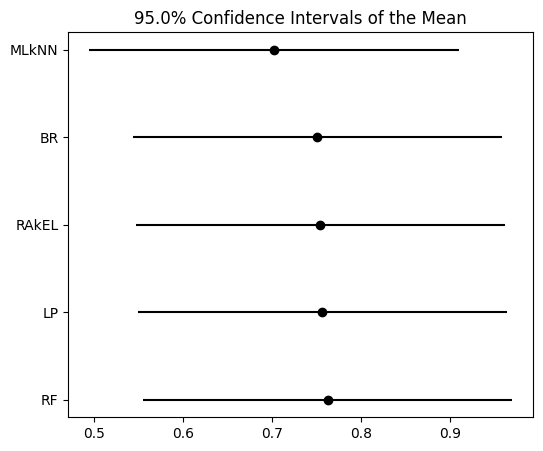


Wilcoxon: MLkNN vs BR
p-valor: 0.125


In [98]:
from autorank import autorank, plot_stats
from scipy.stats import wilcoxon
import matplotlib.pyplot as plt

print("\n===== AUPRC_micro =====")

# tabela
df = build_table(all_results, "auprc_micro")
df = df.dropna()

print(df)

# Friedman + Nemenyi
result = autorank(df, alpha=0.05, order='descending', verbose=True)

print("\nRanking médio:")
print(result.rankdf)

#plot_stats(result)
#plt.show()

plot_stats(result, allow_insignificant=True)
plt.show()

# Wilcoxon (só com os 2 melhores)
means = df.mean().sort_values(ascending=True)
m1, m2 = means.index[:2]

stat, p = wilcoxon(df[m1], df[m2])

print(f"\nWilcoxon: {m1} vs {m2}")
print("p-valor:", p)

Conclusão: Não foram observadas diferenças estatisticamente significativas entre os modelos (p = 0.127). Apesar do Random Forest apresentar o melhor ranking médio, as diferenças são negligenciáveis. O teste de Wilcoxon também não indicou diferença significativa entre os modelos comparados (p = 0.1875).


===== AUPRC_macro =====
                     BR        LP     RAkEL        RF     MLkNN
dataset                                                        
Gram_positive  0.915586  0.932742  0.938632  0.930515  0.887180
CHD_49         0.525957  0.537241  0.528943  0.538259  0.483657
VirusGO        0.940699  0.944740  0.938351  0.936461  0.795935
emotions       0.735895  0.747156  0.735893  0.740640  0.534671
VirusPseAAC    0.349886  0.352312  0.359254  0.377060  0.328424
Fail to reject null hypothesis that data is normal for column BR (p=0.510070>=0.010000)
Fail to reject null hypothesis that data is normal for column LP (p=0.454585>=0.010000)
Fail to reject null hypothesis that data is normal for column RAkEL (p=0.405233>=0.010000)
Fail to reject null hypothesis that data is normal for column RF (p=0.425107>=0.010000)
Fail to reject null hypothesis that data is normal for column MLkNN (p=0.668336>=0.010000)
Using Bartlett's test for homoscedacity of normally distributed data
Fail to reje

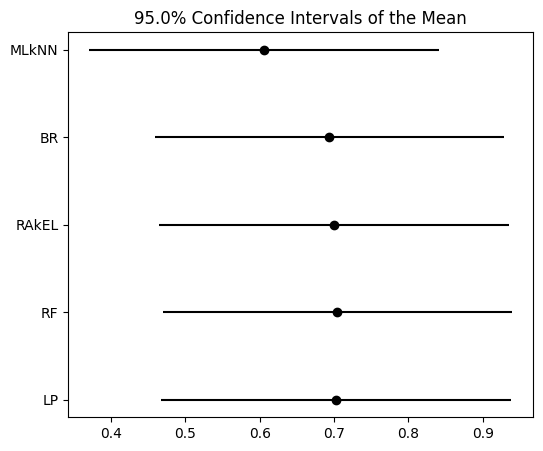


Wilcoxon: MLkNN vs BR
p-valor: 0.0625


In [99]:
from autorank import autorank, plot_stats
from scipy.stats import wilcoxon
import matplotlib.pyplot as plt

print("\n===== AUPRC_macro =====")

# tabela
df = build_table(all_results, "auprc_macro")
df = df.dropna()

print(df)

# Friedman + Nemenyi
result = autorank(df, alpha=0.05, order='descending', verbose=True)

print("\nRanking médio:")
print(result.rankdf)

#plot_stats(result)
#plt.show()

plot_stats(result, allow_insignificant=True)
plt.show()

# Wilcoxon (só com os 2 melhores)
means = df.mean().sort_values(ascending=True)
m1, m2 = means.index[:2]

stat, p = wilcoxon(df[m1], df[m2])

print(f"\nWilcoxon: {m1} vs {m2}")
print("p-valor:", p)

Conclusão: Não foram observadas diferenças estatisticamente significativas entre os modelos (p = 0.276). Embora o Random Forest apresente o melhor ranking médio, as diferenças são negligenciáveis. O teste de Wilcoxon também não indicou diferença significativa entre os modelos comparados (p = 0.625).

#### AUC


===== AUC_micro =====
                     BR        LP     RAkEL        RF     MLkNN
dataset                                                        
Gram_positive  0.992741  0.992251  0.991942  0.991885  0.985998
CHD_49         0.785763  0.791198  0.788706  0.794110  0.760858
VirusGO        0.979013  0.979290  0.981577  0.979385  0.958579
emotions       0.872437  0.874611  0.872242  0.875396  0.763365
VirusPseAAC    0.768864  0.777716  0.776805  0.789049  0.767955
Fail to reject null hypothesis that data is normal for column BR (p=0.274695>=0.010000)
Fail to reject null hypothesis that data is normal for column LP (p=0.251976>=0.010000)
Fail to reject null hypothesis that data is normal for column RAkEL (p=0.221414>=0.010000)
Fail to reject null hypothesis that data is normal for column RF (p=0.196733>=0.010000)
Fail to reject null hypothesis that data is normal for column MLkNN (p=0.023114>=0.010000)
Using Bartlett's test for homoscedacity of normally distributed data
Fail to reject

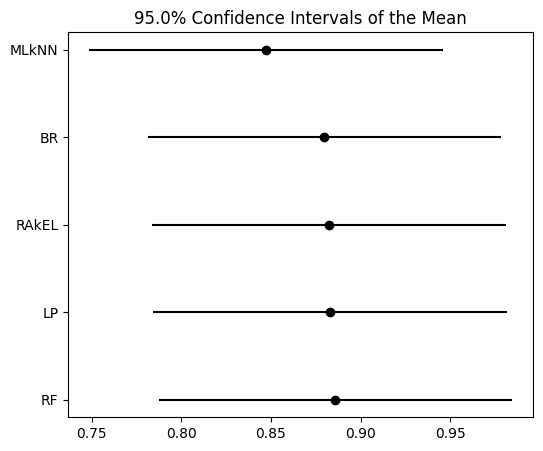


Wilcoxon: MLkNN vs BR
p-valor: 0.0625


In [100]:
from autorank import autorank, plot_stats
from scipy.stats import wilcoxon
import matplotlib.pyplot as plt

print("\n===== AUC_micro =====")

# tabela
df = build_table(all_results, "auc_micro")
df = df.dropna()

print(df)

# Friedman + Nemenyi
result = autorank(df, alpha=0.05, order='descending', verbose=True)

print("\nRanking médio:")
print(result.rankdf)

#plot_stats(result)
#plt.show()

plot_stats(result, allow_insignificant=True)
plt.show()

# Wilcoxon (só com os 2 melhores)
means = df.mean().sort_values(ascending=True)
m1, m2 = means.index[:2]

stat, p = wilcoxon(df[m1], df[m2])

print(f"\nWilcoxon: {m1} vs {m2}")
print("p-valor:", p)

Conclusão: Não foram observadas diferenças estatisticamente significativas entre os modelos (p = 0.265). Embora o Random Forest apresente o melhor ranking médio, as diferenças são negligenciáveis. O teste de Wilcoxon também não indicou diferença significativa entre os modelos comparados (p = 0.4375).


===== AUC_macro =====
                     BR        LP     RAkEL        RF     MLkNN
dataset                                                        
Gram_positive  0.989504  0.989061  0.988732  0.988538  0.976438
CHD_49         0.568273  0.589233  0.575007  0.585367  0.539308
VirusGO        0.976501  0.976569  0.977255  0.975472  0.942499
emotions       0.853308  0.857343  0.853613  0.855372  0.737049
VirusPseAAC    0.603236  0.610504  0.600570  0.638906  0.599473
Fail to reject null hypothesis that data is normal for column BR (p=0.175558>=0.010000)
Fail to reject null hypothesis that data is normal for column LP (p=0.147633>=0.010000)
Fail to reject null hypothesis that data is normal for column RAkEL (p=0.151986>=0.010000)
Fail to reject null hypothesis that data is normal for column RF (p=0.245097>=0.010000)
Fail to reject null hypothesis that data is normal for column MLkNN (p=0.400725>=0.010000)
Using Bartlett's test for homoscedacity of normally distributed data
Fail to reject

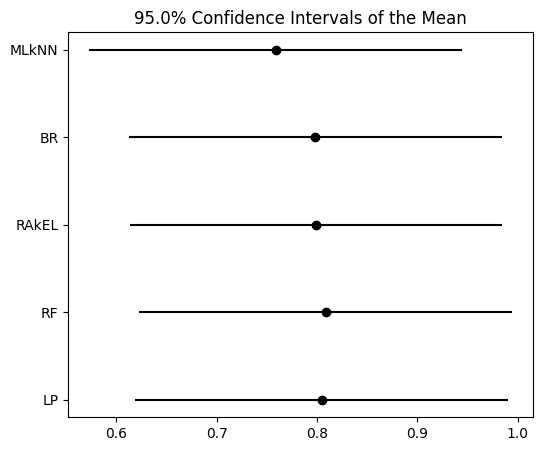


Wilcoxon: MLkNN vs BR
p-valor: 0.0625


In [101]:
from autorank import autorank, plot_stats
from scipy.stats import wilcoxon
import matplotlib.pyplot as plt

print("\n===== AUC_macro =====")

# tabela
df = build_table(all_results, "auc_macro")
df = df.dropna()

print(df)

# Friedman + Nemenyi
result = autorank(df, alpha=0.05, order='descending', verbose=True)

print("\nRanking médio:")
print(result.rankdf)

#plot_stats(result)
#plt.show()

plot_stats(result, allow_insignificant=True)
plt.show()

# Wilcoxon (só com os 2 melhores)
means = df.mean().sort_values(ascending=True)
m1, m2 = means.index[:2]

stat, p = wilcoxon(df[m1], df[m2])

print(f"\nWilcoxon: {m1} vs {m2}")
print("p-valor:", p)

Conclusão: Para a métrica AUC Macro, os testes estatísticos indicaram que não há diferenças estatisticamente significativas entre os modelos avaliados (p = 0.825). Embora o modelo Random Forest tenha apresentado o melhor ranking médio, o tamanho de efeito foi considerado negligenciável. O teste de Wilcoxon entre os dois melhores modelos também não identificou diferença significativa (p = 1.0), reforçando que os desempenhos são equivalentes.